## NOTEBOOK 5 ##

## Visualizations & Business Insights ##

**Objective:** Generate Publication ready charts for all 4 business questions.

**Input:** 
* Raw data : 'data/raw/src/INX_Employee_data.xlsx'
* Processed data : 'data/processed/Employee_Cleaned.csv'
* Trained model : 'best_model.pkl'

**Output:** Charts saved to 'data/processed/' folder

In [36]:
# Import all the libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import pickle 
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
sns.set_theme(style='whitegrid') 
plt.rcParams['figure.dpi'] = 130 
plt.rcParams['font.family'] = 'Dejavu Sans' 
COLORS = {'low':'#E24B4A','good':'#378ADD','excellent':'#1D9E75',
'main':'#185FA5','amber':'#EF9F27','gray':'#888780'} 

In [37]:
from pathlib import Path
BASE = Path(r"c:\Users\Lenovo\Downloads\Employee Performance")   


In [38]:
# Load the data 
import sys
import pickle
sys.path.append(r'C:\Users\Lenovo\Downloads\Employee Performance')  # ← add this
from config import RAW_DATA,CLEANED
data_raw = pd.read_excel(RAW_DATA) 
data = pd.read_csv(CLEANED)
with open(r'C:\Users\Lenovo\Downloads\Employee Performance\models\best_model.pkl','rb') as f:
    model = pickle.load(f) 

X = data.drop(columns=['PerformanceRating']) 
y = data['PerformanceRating'] 


## Visualization - 1 ##

In [39]:
df_processed = pd.read_csv(
    r'C:\Users\Lenovo\\Downloads\Employee Performance\data\processed\Employee_Cleaned.csv'
)

# Drop target + prediction columns added by predict_model.ipynb
cols_to_drop = ['PerformanceRating', 'Predicted_Rating', 'Prob_Low', 
                'Prob_Good', 'Prob_excellent', 'Correct_Prediction']

X = df_processed.drop(columns=[c for c in cols_to_drop if c in df_processed.columns])

print("X shape:", X.shape)           # should be (1200, 26)
print("Model features:", len(model.feature_importances_))  # should be 26

X shape: (1200, 26)
Model features: 26


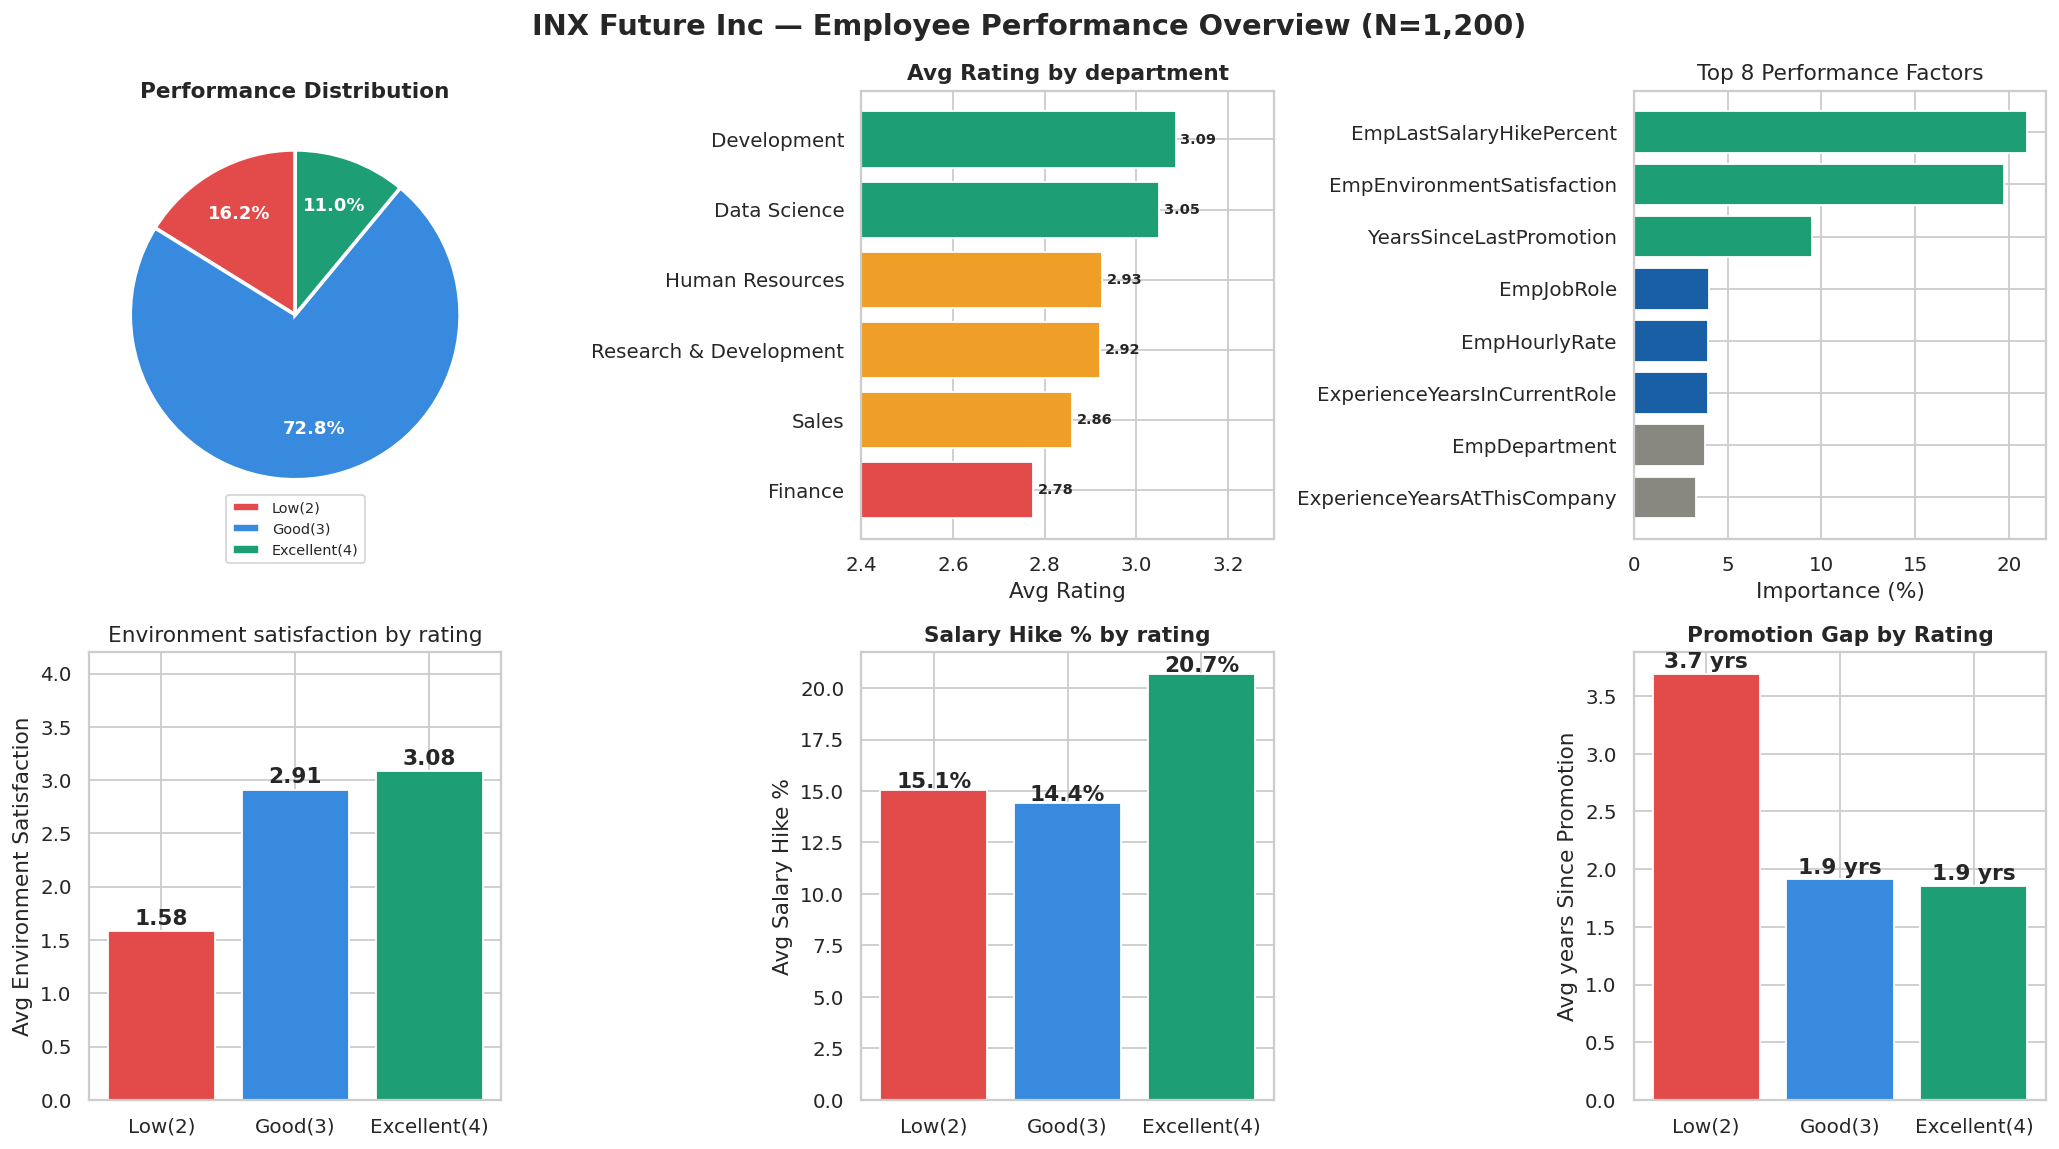

Visualization-1 Saved -> C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization-1_Overview_dashboard.png


In [40]:
#Overall Performance Overview Dashboard (6-panel)
colors_pie = [COLORS['low'], COLORS['good'], COLORS['excellent']]
fig = plt.figure(figsize=(16, 9))
fig.suptitle(
    'INX Future Inc — Employee Performance Overview (N=1,200)',
    fontsize=16, fontweight='bold', y=0.98
)
# Perfromance donut
ax1 = fig.add_subplot(2,3,1) 
counts = data_raw['PerformanceRating'].value_counts().sort_index()
wedges,texts,autotexts = ax1.pie( 
    counts.values,autopct = '%1.1f%%',
    colors = colors_pie,startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    pctdistance=0.7
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold') 
    t.set_color('white') 
ax1.set_title('Performance Distribution',fontweight='bold') 
ax1.legend(['Low(2)','Good(3)','Excellent(4)'],
           loc = 'lower center',bbox_to_anchor=(0.5,-0.12), ncol=1, fontsize=8) 
# Department Avg Rating 
ax2 = fig.add_subplot(2,3,2) 
dept = data_raw.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values() 
bar_c = [COLORS['low'] if v < 2.85 else COLORS['amber'] if v < 2.95 else COLORS['excellent']
         for v in dept.values]
ax2.barh(dept.index, dept.values, color = bar_c, edgecolor ='white') 
ax2.set_xlim(2.4,3.3) 
ax2.set_title('Avg Rating by department', fontweight='bold') 
ax2.set_xlabel('Avg Rating') 
for i, v in enumerate(dept.values):
    ax2.text(v+0.01,i,f'{v:.2f}',va='center',fontsize=8,fontweight='bold') 
# Top 8 Feature Importance
ax3 = fig.add_subplot(2,3,3) 
fi = pd.Series(
    model.feature_importances_,
    index = X.columns
).sort_values(ascending=False).head(8) 
c = [COLORS['excellent'] if i < 3 else COLORS['main'] if i < 6 else COLORS['gray'] for i in range(len(fi))] 
ax3.barh(fi.index[::-1],fi.values[::-1]*100,color = c[::-1],edgecolor='white') 
ax3.set_title('Top 8 Performance Factors') 
ax3.set_xlabel('Importance (%)') 
# Environment satisfaction by rating 
ax4 = fig.add_subplot(2,3,4) 
env_means = data_raw.groupby('PerformanceRating')['EmpEnvironmentSatisfaction'].mean() 
ax4.bar(['Low(2)','Good(3)','Excellent(4)'],env_means.values,color=colors_pie,edgecolor='white') 
ax4.set_ylim(0,4.2) 
ax4.set_ylabel('Avg Environment Satisfaction') 
ax4.set_title('Environment satisfaction by rating') 
for i,v in enumerate(env_means.values):
    ax4.text(i, v +0.06, f'{v:.2f}', ha='center', fontweight='bold') 
# Salary hike by rating
ax5 =  fig.add_subplot(2,3,5) 
hike_means = data_raw.groupby('PerformanceRating')['EmpLastSalaryHikePercent'].mean() 
ax5.bar(['Low(2)','Good(3)','Excellent(4)'],hike_means.values,
        color=colors_pie, edgecolor='white') 
ax5.set_ylabel('Avg Salary Hike %') 
ax5.set_title('Salary Hike % by rating',fontweight='bold')
for i, v in enumerate(hike_means.values):
    ax5.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold') 
# Years Since Promotion 
ax6 = fig.add_subplot(2,3,6)
promo_means = data_raw.groupby('PerformanceRating')['YearsSinceLastPromotion'].mean()
ax6.bar(['Low(2)','Good(3)','Excellent(4)'],promo_means.values,
        color = colors_pie,edgecolor='white') 
ax6.set_ylabel('Avg years Since Promotion') 
ax6.set_title('Promotion Gap by Rating',fontweight='bold') 
for i, v in enumerate(promo_means.values):
    ax6.text(i,v + 0.05,f'{v:.1f} yrs', ha = 'center',fontweight='bold') 
plt.tight_layout() 
save_path1 = (r'C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization-1_Overview_dashboard.png') 
plt.savefig(save_path1,bbox_inches='tight',dpi=150) 
plt.show()
print(f'Visualization-1 Saved -> {save_path1}') 

## Visualization-2 ##

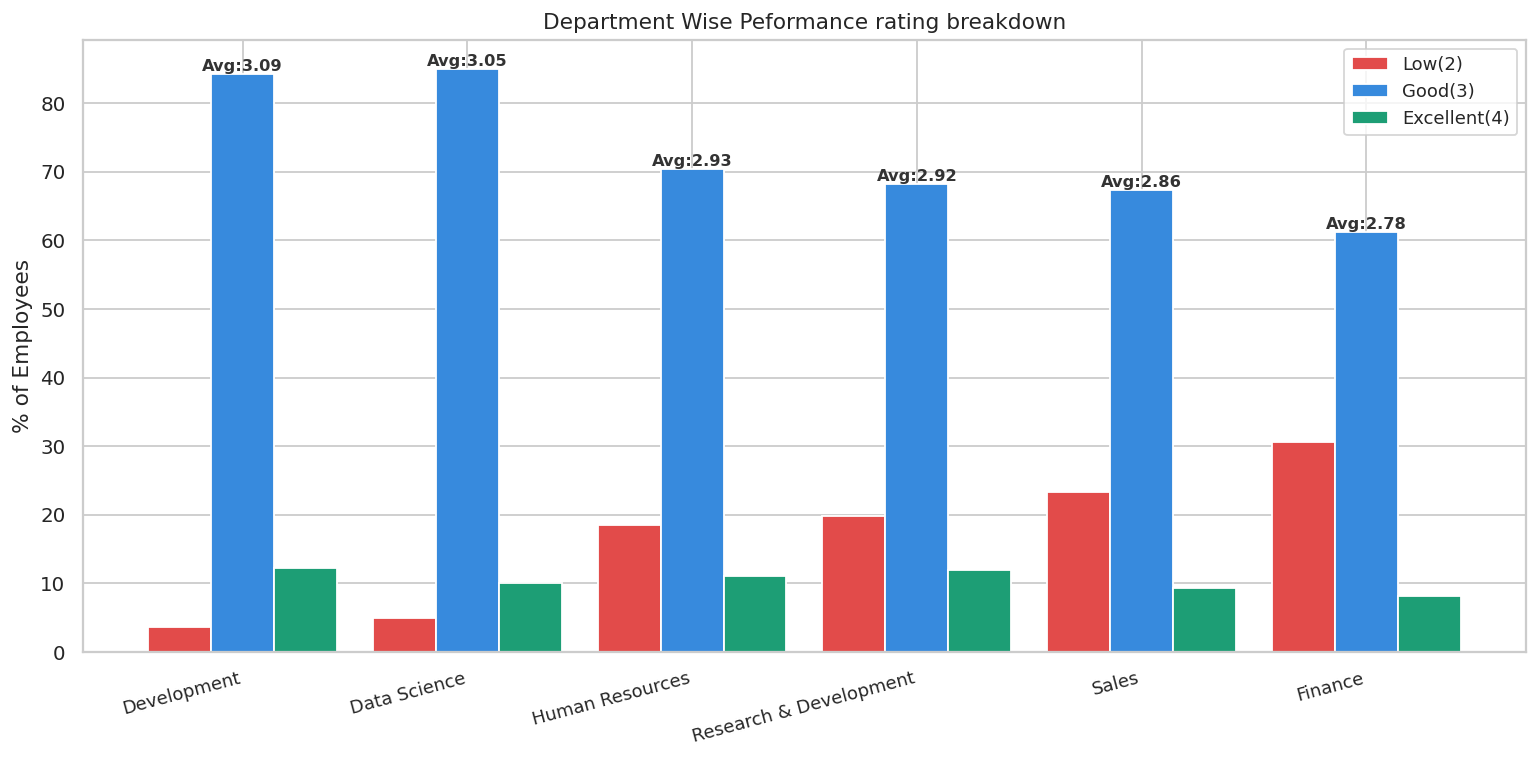

Visulaization 2 saved → C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization-2_Department_breakdown.png


In [41]:
dept_detail = data_raw.groupby('EmpDepartment').agg(
    Employees = ('PerformanceRating','count') ,
    Avg_Rating  = ('PerformanceRating','mean') ,
    pct_Low = ('PerformanceRating',lambda x: (x == 2).sum() / len(x) *100),
    pct_Good = ('PerformanceRating',lambda x: (x==3).sum() / len(x) * 100),
    pct_Excel = ('PerformanceRating',lambda x: (x == 4).sum() / len(x) * 100),).sort_values('Avg_Rating',ascending=False)
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(dept_detail)) 
w = 0.28 
ax.bar(x - w, dept_detail['pct_Low'], w, label = 'Low(2)', color=COLORS['low'],edgecolor='white') ,
ax.bar(x, dept_detail['pct_Good'],w, label = 'Good(3)', color = COLORS['good'], edgecolor = 'white'), 
ax.bar(x + w, dept_detail['pct_Excel'], w,label='Excellent(4)',color = COLORS['excellent'],edgecolor='white') 
ax.set_xticks(x)
ax.set_xticklabels(dept_detail.index, fontsize=10, rotation=15, ha='right') 
ax.set_ylabel('% of Employees') 
ax.set_title('Department Wise Peformance rating breakdown') 
ax.legend(fontsize=10)
# Adding average rating annotation on top of each group 
for i, (dept_name,row) in enumerate(dept_detail.iterrows()):
    ax.text(i, max(row['pct_Low'], row['pct_Good'], row['pct_Excel']) + .5,
        f"Avg:{row['Avg_Rating']:.2f}", ha='center', fontsize=9, fontweight='bold', color='#333')
plt.tight_layout()
save_path2 = (r'C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization-2_Department_breakdown.png')
plt.savefig(save_path2,bbox_inches = 'tight',dpi=150) 
plt.show()
print(f'Visulaization 2 saved → {save_path2}')

## Visualization - 3 ## 

Visualization 3 saved → C:\Users\Lenovo\Downloads\Employee Performance\data\processed\VIZ_03_feature_importance.png


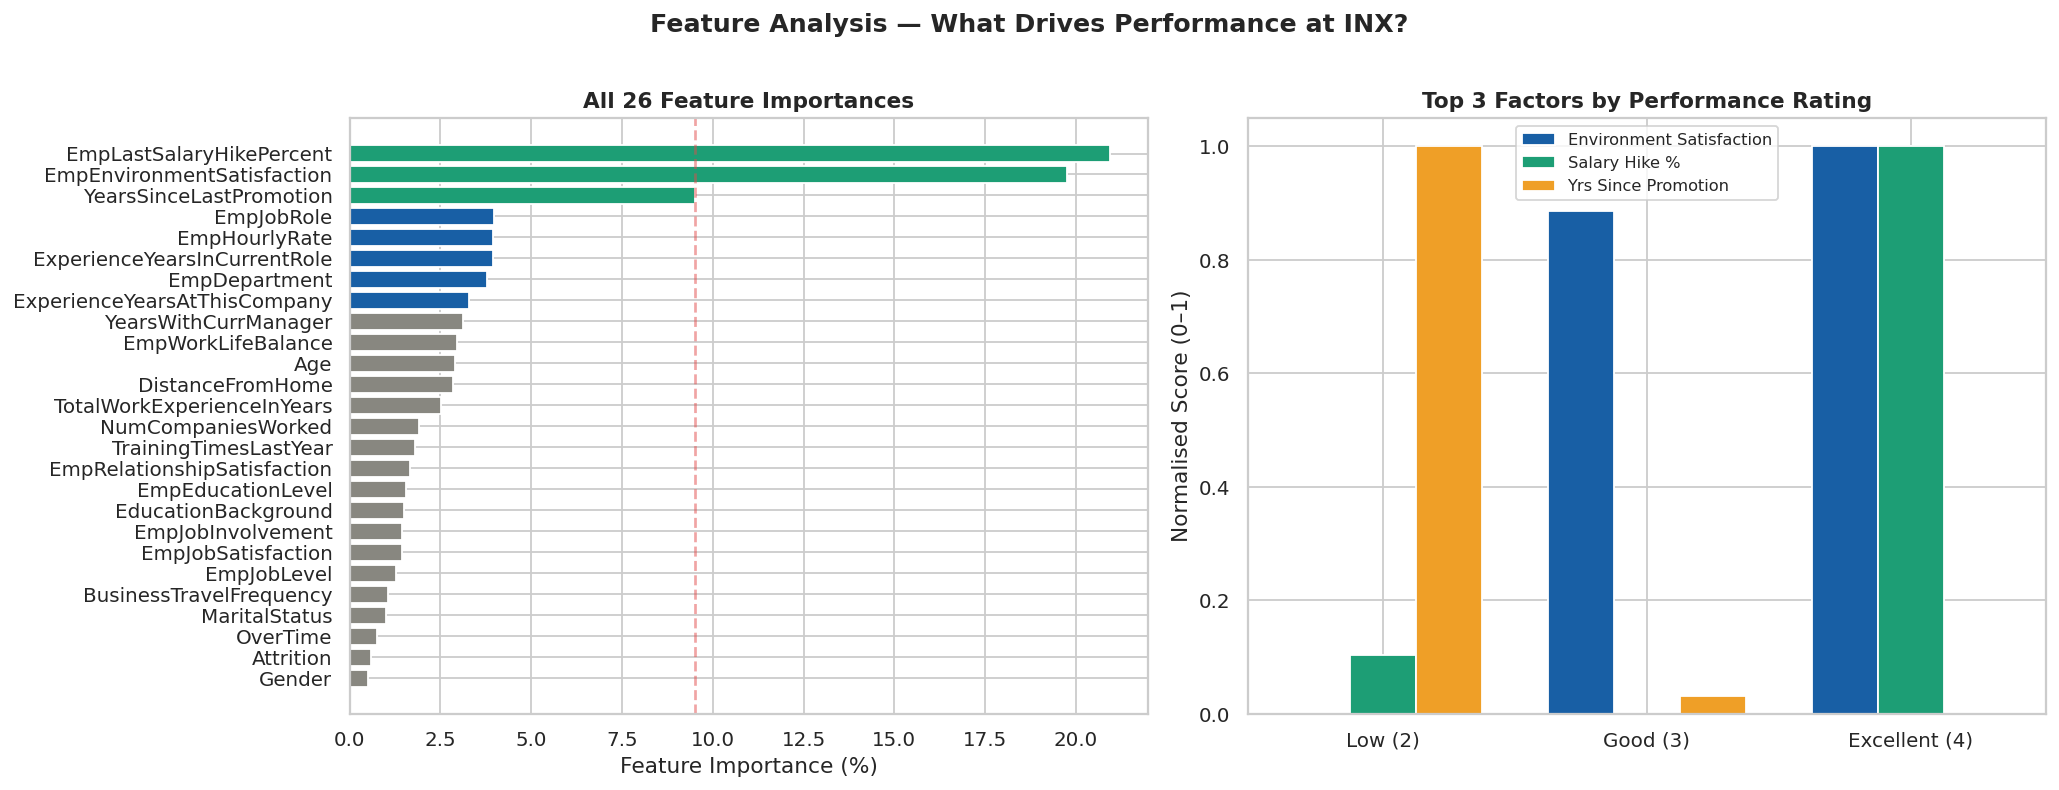

In [ ]:
# Feature Importance with Business Context
fi_series = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left: All 26 feature importances
colors_fi=[
COLORS['excellent'] if i < 3 else COLORS['main'] if i < 8 else COLORS['gray']
for i in range(len(fi_series))
]
axes[0].barh(
    fi_series.index[::-1],
    fi_series.values[::-1] * 100,
    color=colors_fi[::-1], edgecolor='white'
)
axes[0].set_xlabel('Feature Importance (%)')
axes[0].set_title('All 26 Feature Importances', fontweight='bold')
axes[0].axvline(
    x=fi_series.iloc[2] * 100, color='#E24B4A', linestyle='--', alpha=0.5
)

# Right: Top 3 factors normalised by rating 
top3        = ['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion']
top3_labels = ['Environment Satisfaction',  'Salary Hike %',            'Yrs Since Promotion']

data_norm = {}
for col in top3:
    means = data_raw.groupby('PerformanceRating')[col].mean()
    mn, mx = means.min(), means.max()
    data_norm[col] = ((means - mn) / (mx - mn)).values

bar_w = 0.25
x = np.arange(3)

axes[1].bar(x - bar_w, data_norm[top3[0]], bar_w, label=top3_labels[0], color='#185FA5', edgecolor='white')
axes[1].bar(x,         data_norm[top3[1]], bar_w, label=top3_labels[1], color='#1D9E75', edgecolor='white')
axes[1].bar(x + bar_w, data_norm[top3[2]], bar_w, label=top3_labels[2], color='#EF9F27', edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Low (2)', 'Good (3)', 'Excellent (4)'])
axes[1].set_ylabel('Normalised Score (0–1)')
axes[1].set_title('Top 3 Factors by Performance Rating', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Feature Analysis — What Drives Performance at INX?',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
save_path3 = r'C:\Users\Lenovo\Downloads\Employee Performance\data\processed\VIZ_03_feature_importance.png'
plt.savefig(save_path3, bbox_inches='tight', dpi=150)
print(f'Visualization 3 saved → {save_path3}')
plt.show()


## Visualization 4 ##


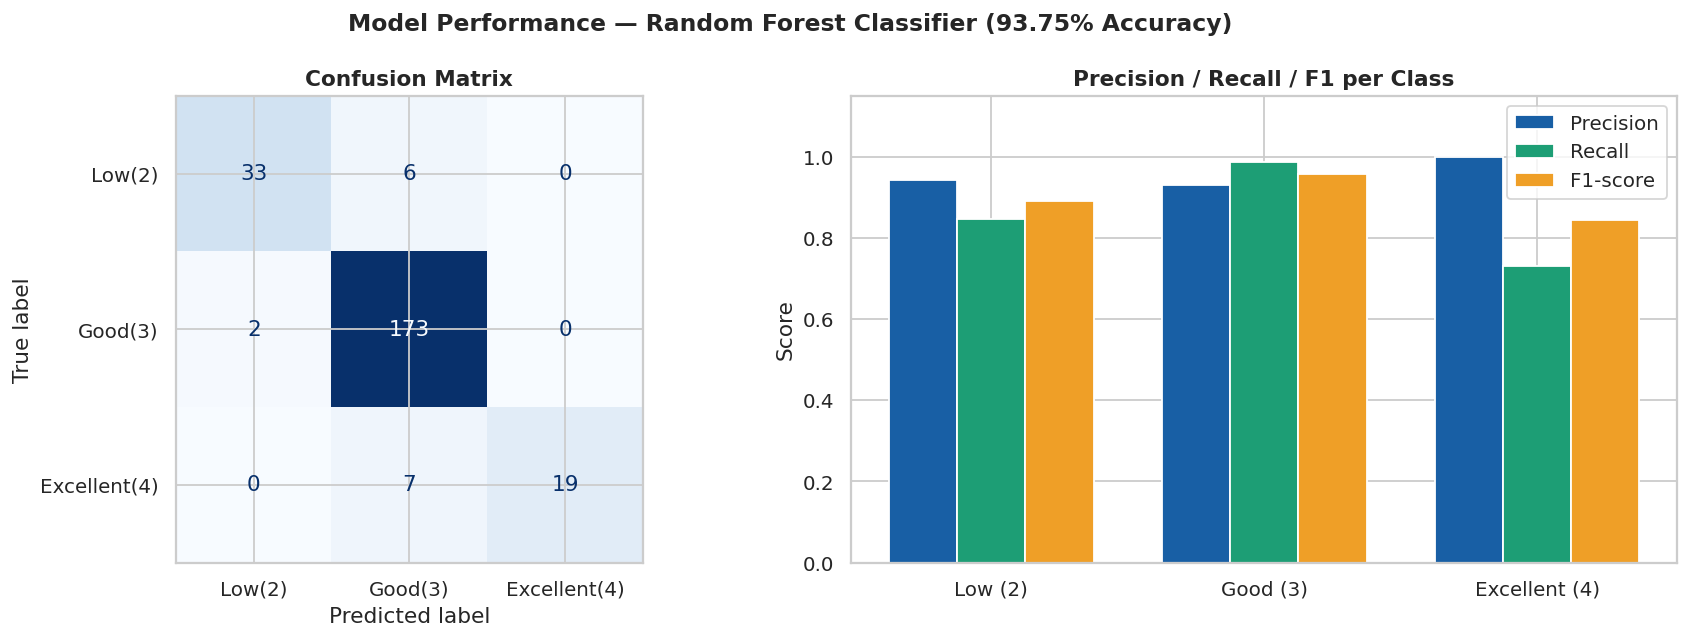

Visualization 4 saved → C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization_04_model_performance.png


In [43]:
# Model Performance Summary
# Re-split exactly as in train_model.ipynb (same random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Use the already-trained model — no refit needed
y_pred = model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Model Performance — Random Forest Classifier (93.75% Accuracy)',
    fontweight='bold', fontsize=13
)
#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low(2)', 'Good(3)', 'Excellent(4)']) \
    .plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')
# Per-class Precision / Recall / F1 
report  = classification_report(y_test, y_pred, output_dict=True)
classes = ['2', '3', '4']
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(classes))
w = 0.25
metric_colors = [COLORS['main'], COLORS['excellent'], COLORS['amber']]
for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    vals = [report[c][metric] for c in classes]
    axes[1].bar(x + i * w, vals, w, label=metric.capitalize(),
                color=color, edgecolor='white')

axes[1].set_xticks(x + w)
axes[1].set_xticklabels(['Low (2)', 'Good (3)', 'Excellent (4)'])
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 per Class', fontweight='bold')
axes[1].legend()
plt.tight_layout()
save_path4 = r'C:\Users\Lenovo\Downloads\Employee Performance\data\processed\Visualization_04_model_performance.png'
plt.savefig(save_path4, bbox_inches='tight', dpi=150)
plt.show()
print(f'Visualization 4 saved → {save_path4}')


## Visualization-5 ##

SHAP — Global Feature Importance
Computing SHAP values (takes ~15 seconds)...
Done.



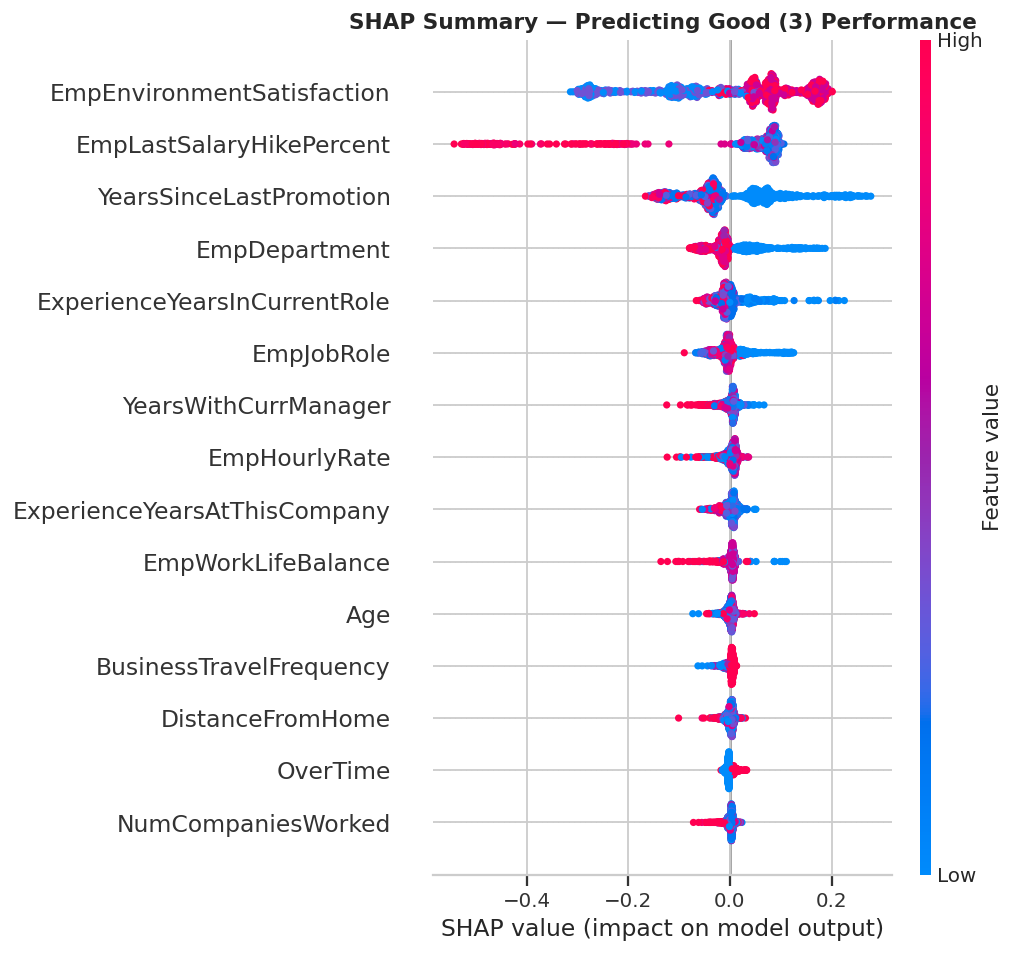

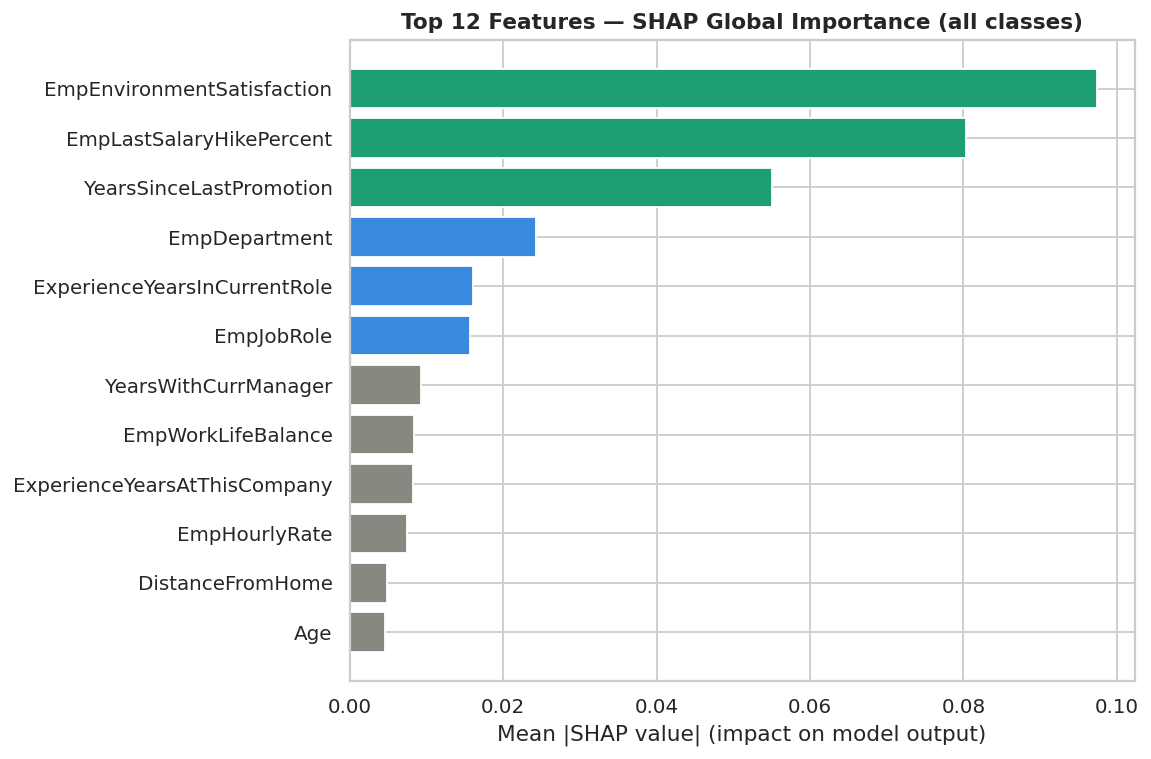

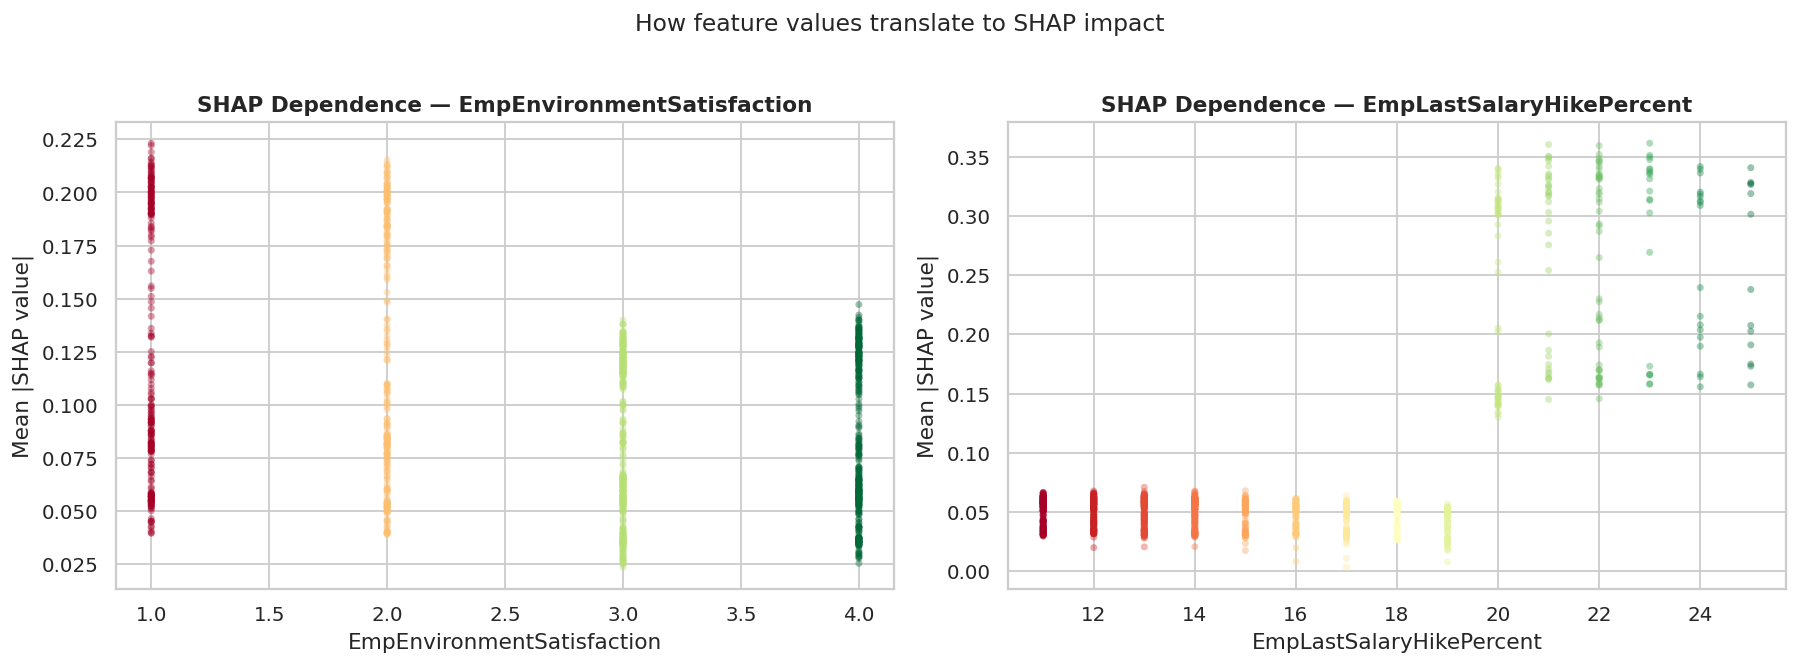

In [44]:
import shap
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("C:/Users/YourName/Employee Performance Analysis")  # ← change this

print("=" * 55)
print("SHAP — Global Feature Importance")
print("=" * 55)
print("Computing SHAP values (takes ~15 seconds)...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap_array = np.array(shap_values)               # (1200, 26, 3)
shap_abs_mean = np.abs(shap_array).mean(axis=2)  # (1200, 26)
print("Done.\n")

# ── 05A Summary Plot ──────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_array[:, :, 1],   # (1200, 26) — class 1 = Good(3)
    X,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Predicting Good (3) Performance', fontweight='bold')
plt.tight_layout()
plt.savefig('Visualization_05A_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 05B Bar Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

mean_shap = pd.Series(
    shap_abs_mean.mean(axis=0),   # (26,) — avg across samples
    index=X.columns
).sort_values(ascending=False).head(12)

colors_shap = ['#1D9E75' if i < 3 else '#378ADD' if i < 6 else '#888780'
               for i in range(len(mean_shap))]

ax.barh(mean_shap.index[::-1], mean_shap.values[::-1],
        color=colors_shap[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (impact on model output)')
ax.set_title('Top 12 Features — SHAP Global Importance (all classes)', fontweight='bold')
plt.tight_layout()
plt.savefig('Visualization_05B_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
# 05D Dependence Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent']):
    feat_idx = list(X.columns).index(feat)
    shap_feat = shap_abs_mean[:, feat_idx]   # (1200,)
    ax.scatter(X[feat], shap_feat,
               alpha=0.4, c=X[feat],
               cmap='RdYlGn', s=15, edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('Mean |SHAP value|')
    ax.set_title(f'SHAP Dependence — {feat}', fontweight='bold')

plt.suptitle('How feature values translate to SHAP impact', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('Visualization_05D_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## Most Important Technique ##
SHAP (SHapley Additive Explanations) was the most critical 
technique — it moved beyond accuracy to explain WHY the model 
makes each prediction, making results interpretable for 
non-technical HR stakeholders.

In [45]:
print('=' * 60)
print('All 4 Visualization Outputs Saved')
print('=' * 60)
outputs = [
    ('Visualization_01_overview_dashboard.png',   '6-panel performance overview'),
    ('Visualization_02_department_breakdown.png', 'Department-wise rating breakdown'),
    ('Visualization_03_feature_importance.png',   'Feature importance + top 3 factors'),
    ('Visualization_04_model_performance.png',    'Confusion matrix + Precision/Recall/F1'),
    ('visualization_05a_shap_summary.png' ,       'Shap  Global Summary plot'),
    ('visualization_05(B)_shap_bar.png' ,         'Shap Bar plot(Mean Absolute Error)'),
    ('visualization_05(C)_shap_employee_explanation.png','Shap for a Single at-Risk Employee'),
]
for fname, desc in outputs:
    print(f'  {fname:<45} → {desc}')
print('=' * 60)
print(r'Location: C:\Users\Lenovo\Downloads\Employee Performance\data\processed')

All 4 Visualization Outputs Saved
  Visualization_01_overview_dashboard.png       → 6-panel performance overview
  Visualization_02_department_breakdown.png     → Department-wise rating breakdown
  Visualization_03_feature_importance.png       → Feature importance + top 3 factors
  Visualization_04_model_performance.png        → Confusion matrix + Precision/Recall/F1
  visualization_05a_shap_summary.png            → Shap  Global Summary plot
  visualization_05(B)_shap_bar.png              → Shap Bar plot(Mean Absolute Error)
  visualization_05(C)_shap_employee_explanation.png → Shap for a Single at-Risk Employee
Location: C:\Users\Lenovo\Downloads\Employee Performance\data\processed


## Summary ##


**Key Business Insights:**

| # | Finding | Action |
|---|---------|--------|
| 1 | **EmpLastSalaryHikePercent** is the top predictor | Ensure competitive hike cycles |
| 2 | **EmpEnvironmentSatisfaction** separates Low vs Excellent clearly | Run quarterly satisfaction surveys |
| 3 | **YearsSinceLastPromotion** — long gaps → lower performance | Flag employees with >4 yrs without promotion |
| 4 | Development & Finance departments have highest avg ratings | Study their practices for replication |
| 5 | Model accuracy: **93.75%** with Random Forest | Reliable for HR screening decisions |

## Conclusion ##

**Notebook-5 Complete**
* Generated 7 charts for clear understanding.
* SHAP analysis confirmed the top 3 business factors.
* All charts saved to data/processed.
* project Pipeline is completed.